In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import os

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import icarogw
import healpy as hp
from  astropy.cosmology import FlatLambdaCDM
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16


Config not imported, automatically decides between Numpy and Cupy
Error in importing cupy


/Users/ulyana.dupletsa/miniconda3/envs/icaro_gwfish/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## N-body maps

In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
nside = 16
npix = hp.nside2npix(nside)
lmax = 3*nside 

# redhsift range for reference
zmin = 0.005
zmax = 3.025

H0_value = 67.7
# Reference cosmology
cosmo_ref = icarogw.cosmology.astropycosmology(zmax=20.)
cosmo_ref.build_cosmology(FlatLambdaCDM(H0=H0_value,Om0=0.308)) 

In [5]:
PATH_TO_DENSITY_MATRIX = '../../hi_data/'
density_matrix = pd.read_hdf(PATH_TO_DENSITY_MATRIX + 'map4icaro_lmax' + str(lmax) + '_zmin' + str(zmin) + '_zmax' + str(zmax) + '_nside' + str(nside) + '.hdf5').to_numpy()

In [6]:
redshift_grid = np.array([0.005, 0.015, 0.035, 0.06 , 0.085, 0.11 , 0.135, 0.17 , 0.205,
        0.24 , 0.28 , 0.32 , 0.36 , 0.405, 0.455, 0.505, 0.56 , 0.62 ,
        0.68 , 0.745, 0.82 , 0.895, 0.975, 1.06 , 1.155, 1.26 , 1.365,
        1.485, 1.615, 1.755, 1.905, 2.05 , 2.205, 2.39 , 2.585, 2.795,
        3.025])
pixel_grid = np.arange(0, npix, 1).astype(int) # generates an array of (integer) numbers from 0 to npix-1
HI = icarogw.HI.HI_map(redshift_grid,pixel_grid,density_matrix, bGW=1, alphaGW=0)

In [7]:
from scipy.ndimage import gaussian_filter1d
gaussian_sigma = 6.5

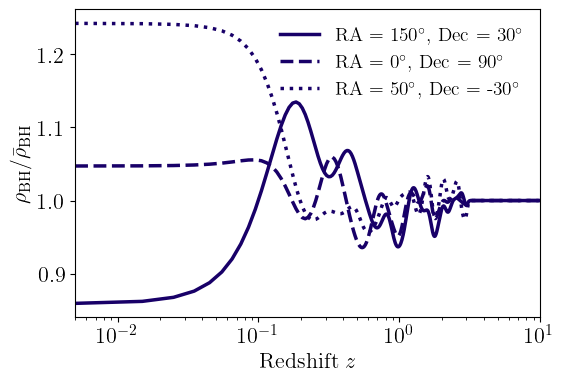

In [ ]:
fig = plt.figure(figsize=(6,4))
my_linewidth = 2.5
pixx1 = 762 # pick a pixel number (in 0 to npix-1) to plot the density of hydrogen as function of redshift
ra  = 150   # degrees
dec = 30     # degrees
z_plot = np.linspace(0.005,10,1000)
pixels_array = pixx1*np.ones_like(z_plot)
gc = HI.drho_dzdomega(z_plot,pixels_array,cosmo_ref)
# smooth the data points
gc_smooth = gaussian_filter1d(gc, sigma=gaussian_sigma)
plt.semilogx(z_plot,gc_smooth,label=r'\rm RA = {:.0f}$^{{\circ}}$, Dec = {:.0f}$^{{\circ}}$'.format(ra, dec), linewidth=my_linewidth, color=ska_color_purple, linestyle='solid')
pixx2 = 0
ra  = 0.0   # degrees
dec = 90.0     # degrees
pixels_array = pixx2*np.ones_like(z_plot)
gc = HI.drho_dzdomega(z_plot,pixels_array,cosmo_ref)
gc_smooth = gaussian_filter1d(gc, sigma=gaussian_sigma)
plt.semilogx(z_plot,gc_smooth,label=r'\rm RA = {:.0f}$^{{\circ}}$, Dec = {:.0f}$^{{\circ}}$'.format(ra, dec), linewidth=my_linewidth, color=ska_color_purple, linestyle='dashed')
pixx3 = 2280
ra  = 50   # degrees
dec = -30     # degrees
pixels_array = pixx3*np.ones_like(z_plot)
gc = HI.drho_dzdomega(z_plot,pixels_array,cosmo_ref)
gc_smooth = gaussian_filter1d(gc, sigma=gaussian_sigma)
plt.semilogx(z_plot,gc_smooth,label=r'\rm RA = {:.0f}$^{{\circ}}$, Dec = {:.0f}$^{{\circ}}$'.format(ra, dec), linewidth=my_linewidth, color=ska_color_purple, linestyle='dotted')
plt.xscale('log')
#plt.yscale('log')
plt.xlim(0.005, 10)
#gc = HI.drho_dzdomega(z_plot,pixels_array,cosmo_ref,average=True)
#plt.plot(z_plot,gc,label = 'Averaged over sky', linestyle='dashed', linewidth=2.5)
#plt.yscale('log')
plt.xlabel(r'\rm Redshift $z$', fontsize =16)
plt.ylabel(r'$\rho_{\rm BH} / \bar{\rho}_{\rm BH}$', fontsize =16)
plt.legend(fontsize=14, frameon=False)
plt.savefig('HI_density_profile_smooth.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Choose lines of sight

In [41]:
ra  = 150.0   # degrees
dec = 30.0     # degrees

theta = np.radians(90.0 - dec)
phi   = np.radians(ra)

pix = hp.ang2pix(nside, theta, phi)

print("Pixel number =", pix)

Pixel number = 762


In [42]:
ra  = 0.0   # degrees
dec = 90.0     # degrees

theta = np.radians(90.0 - dec)
phi   = np.radians(ra)

pix = hp.ang2pix(nside, theta, phi)

print("Pixel number =", pix)

Pixel number = 0


In [43]:
ra  = 50   # degrees
dec = -30     # degrees

theta = np.radians(90.0 - dec)
phi   = np.radians(ra)

pix = hp.ang2pix(nside, theta, phi)

print("Pixel number =", pix)

Pixel number = 2280
